In [1]:
#Import libraries and specify paths

import pandas as pd
import numpy  as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

import shap

import time
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.metrics import confusion_matrix

#import pytorch since tensorflow is not supporting in python 3.14
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

torch.manual_seed(42)

print("Librarties imported")

test_csv=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Testing and Training\IoT_NID_test.csv"
train_csv=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Testing and Training\IoT_NID_train.csv"

print("Paths are set")

Librarties imported
Paths are set


In [2]:
#load train and test data

train_df=pd.read_csv(train_csv)
test_df=pd.read_csv(test_csv)

print(f"Train CSV: {train_df.shape}")
print(f"Test CSV: {test_df.shape}")

print(f"\nTrain label Distribution: {train_df['label'].value_counts().to_dict()}")
print(f"\nTest label Distribution: {test_df['label'].value_counts().to_dict()}")

Train CSV: (32000, 103)
Test CSV: (8000, 103)

Train label Distribution: {0: 16000, 1: 16000}

Test label Distribution: {1: 4000, 0: 4000}


In [3]:
#Separate features and label

feature_columns=[feature for feature in train_df.columns if feature!='label']

X_train=train_df[feature_columns]
y_train=train_df['label']

X_test=test_df[feature_columns]
y_test=test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

X_train shape: (32000, 102)
X_test shape: (8000, 102)
y_train distribution: {0: 16000, 1: 16000}
y_test distribution: {1: 4000, 0: 4000}


In [4]:
#DNN Architecture

class TorchDNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

class DNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42):
        self.epochs=epochs
        self.batch_size=batch_size
        self.lr=lr
        self.patience=patience
        self.random_state=random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)

        X=np.asarray(X, dtype=np.float32)
        y=np.asarray(y, dtype=np.float32).reshape(-1,1)

        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.1, random_state=self.random_state, stratify=y)

        self.model_= TorchDNN(X.shape[1])
        optimizer=torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        loss_function=nn.BCELoss()

        X_tr_t = torch.tensor(X_tr)
        y_tr_t = torch.tensor(y_tr)
        X_val_t = torch.tensor(X_val)
        y_val_t = torch.tensor(y_val)

        best_val_loss = float('inf')
        best_state=None
        epoch_no_improve=0
        n_samples=X_tr_t.shape[0]

        for epoch in range(self.epochs):
            self.model_.train()
            permutation=torch.randperm(n_samples)

            for i in range (0, n_samples, self.batch_size):
                idx=permutation[i : i + self.batch_size]
                batch_X, batch_y = X_tr_t[idx], y_tr_t[idx]

                optimizer.zero_grad()
                outputs=self.model_(batch_X)
                loss=loss_function(outputs, batch_y)
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss=loss_function(self.model_(X_val_t), y_val_t).item()

            if val_loss < best_val_loss:
                best_val_loss=val_loss
                best_state={k: v.clone() for k, v in self.model_.state_dict().items()}
                epoch_no_improve=0
            else:
                epoch_no_improve=epoch_no_improve+1
                if epoch_no_improve >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.classes_=np.array([0,1])
        return self

    def predict_proba(self,X):
        X=np.asarray(X, dtype=np.float32)
        self.model_.eval()
        with torch.no_grad():
            probs=self.model_(torch.tensor(X)).numpy().flatten()
        return np.column_stack([1-probs, probs])

    def predict(self,X):
        probs=self.predict_proba(X)[:,1]
        return (probs>=0.5).astype(int)

# Definition of all models

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'DNN': DNNClassifier(epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42)
}

print("Models Defined:")
for i in models:
    print(i)

Models Defined:
Decision Tree
Random Forest
KNN
SVM
Logistic Regression
XGBoost
DNN


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cross_validation_results=[]

print("Running 5-fold Cross-validation on training set....")

for model_name, model in models.items():
    print(f"Cross Validating {model_name}....")

    cross_validadtion_scores=cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")

    cross_validation_results.append({
        "Model": model_name,
        "CV Mean F1": round(cross_validadtion_scores.mean(),4),
        "CV Std F1": round(cross_validadtion_scores.std(),4),
        "CV Min F1": round(cross_validadtion_scores.min(),4),
        "CV Max F1": round(cross_validadtion_scores.max(),4)
    })

    print(f"Fold Scores: {[round(s,4) for s in cross_validadtion_scores]}")
    print(f"Mean F1: {cross_validadtion_scores.mean()}")
    print(f"\nStd F1: {cross_validadtion_scores.std()}")

cross_validation_results_df=pd.DataFrame(cross_validation_results)
cross_validation_results_df=cross_validation_results_df.sort_values('CV Mean F1', ascending =False).reset_index(drop=True)
print("Cross Validation Results:\n")
print(cross_validation_results_df.to_string(index=False))

Running 5-fold Cross-validation on training set....
Cross Validating Decision Tree....
Fold Scores: [np.float64(0.9998), np.float64(0.9995), np.float64(0.9998), np.float64(0.9998), np.float64(0.9995)]
Mean F1: 0.9997186767326252

Std F1: 0.00015315294410905104
Cross Validating Random Forest....
Fold Scores: [np.float64(0.9998), np.float64(1.0), np.float64(0.9998), np.float64(0.9997), np.float64(0.9997)]
Mean F1: 0.9998124511581381

Std F1: 0.00011696595616169378
Cross Validating KNN....
Fold Scores: [np.float64(0.9991), np.float64(0.9988), np.float64(0.9991), np.float64(0.9995), np.float64(0.9977)]
Mean F1: 0.9988139332485421

Std F1: 0.0006280117567536927
Cross Validating SVM....
Fold Scores: [np.float64(0.9967), np.float64(0.9986), np.float64(0.9986), np.float64(0.9986), np.float64(0.998)]
Mean F1: 0.998096903376917

Std F1: 0.0007264870345562585
Cross Validating Logistic Regression....
Fold Scores: [np.float64(0.9972), np.float64(0.9991), np.float64(0.9986), np.float64(0.9994), np.f

Training Decision Tree....
Model Name: Decision Tree
Accuracy 0.999875
Precision: 1.0
Recall: 0.99975
F1-Score: 0.9998749843730467
Training Time: 1.3713197708129883 seconds
Testing Time: 0.012166738510131836 seconds


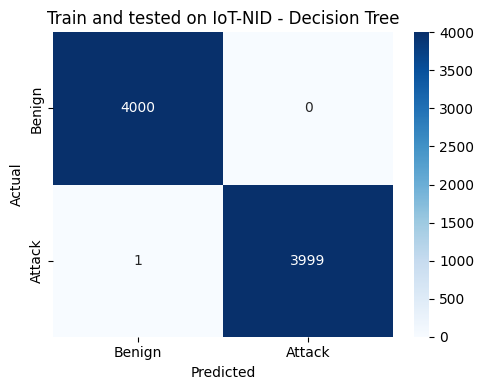

Training Random Forest....
Model Name: Random Forest
Accuracy 0.999875
Precision: 1.0
Recall: 0.99975
F1-Score: 0.9998749843730467
Training Time: 15.58619475364685 seconds
Testing Time: 0.06736254692077637 seconds


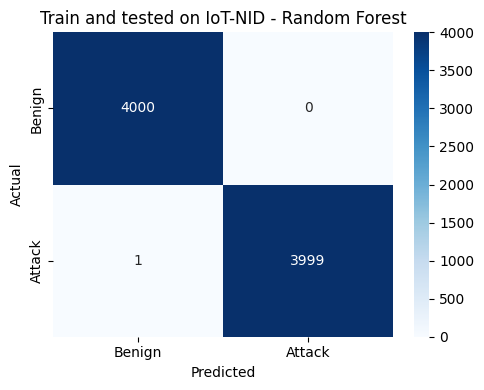

Training KNN....
Model Name: KNN
Accuracy 0.9995
Precision: 0.999000999000999
Recall: 1.0
F1-Score: 0.9995002498750625
Training Time: 0.03843379020690918 seconds
Testing Time: 1.953181505203247 seconds


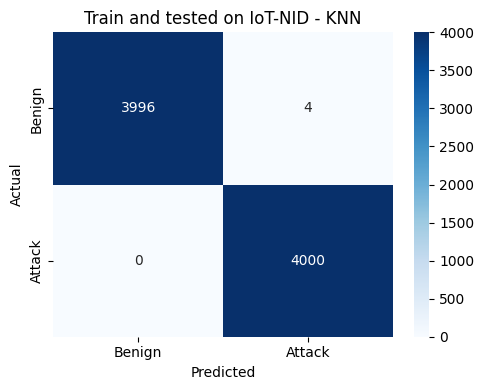

Training SVM....
Model Name: SVM
Accuracy 0.998875
Precision: 0.9977550511349463
Recall: 1.0
F1-Score: 0.9988762642027719
Training Time: 24.564263582229614 seconds
Testing Time: 0.9159872531890869 seconds


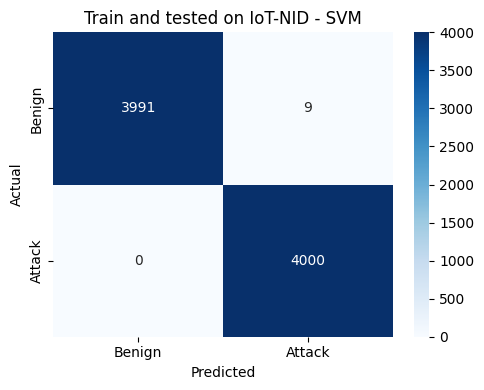

Training Logistic Regression....
Model Name: Logistic Regression
Accuracy 0.999
Precision: 0.999
Recall: 0.999
F1-Score: 0.999
Training Time: 1.252201795578003 seconds
Testing Time: 0.010037899017333984 seconds


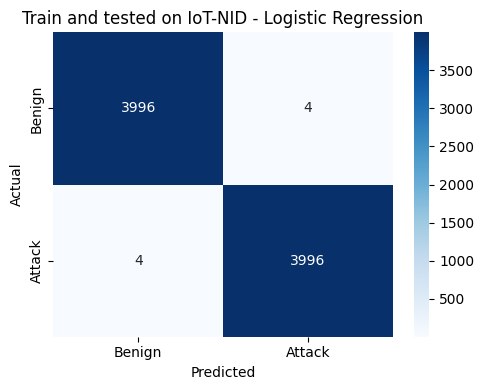

Training XGBoost....
Model Name: XGBoost
Accuracy 0.999875
Precision: 1.0
Recall: 0.99975
F1-Score: 0.9998749843730467
Training Time: 2.464514970779419 seconds
Testing Time: 0.02192854881286621 seconds


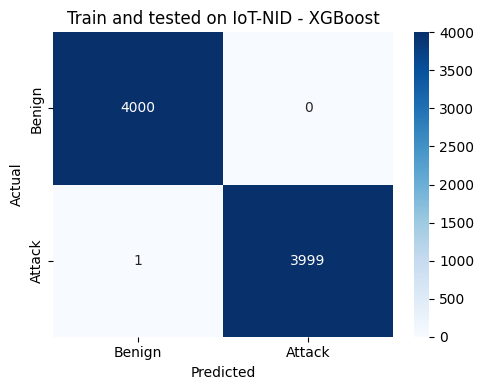

Training DNN....
Model Name: DNN
Accuracy 0.9995
Precision: 0.999000999000999
Recall: 1.0
F1-Score: 0.9995002498750625
Training Time: 13.922777652740479 seconds
Testing Time: 0.01266026496887207 seconds


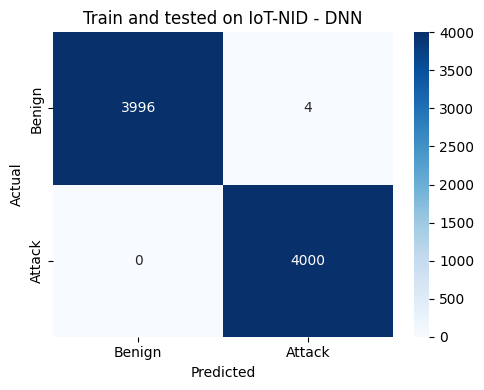


 All models are trained and evaluated


In [6]:
#Train and evaluate all models
import time
results=[]

for model_name, model in models.items():
    print(f"Training {model_name}....")

    #train the model on train data
    start_time=time.time()
    model.fit(X_train, y_train)
    end_time=time.time()
    training_time=end_time-start_time

    #predict on test data
    start_time=time.time()
    y_pred=model.predict(X_test)
    end_time=time.time()
    testing_time=end_time-start_time
    
    #metrics calculation
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    #Storing results
    results.append({
         'Model': model_name,
         'Accuracy': round(accuracy,4),
         'Precision': round(precision,4),
         'Recall': round(recall,4),
         'F1-Score': round(f1,4),
         'Training Time (S)': training_time,
         'Testing Time (S)': testing_time
     })
    print(f"Model Name: {model_name}")
    print(f"Accuracy {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Training Time: {training_time} seconds")
    print(f"Testing Time: {testing_time} seconds")

    #plot confusion matrix,
    cm=confusion_matrix(y_test, y_pred)
    fig,ax=plt.subplots(figsize=(5,4))
    sbn.heatmap(
    cm, annot=True, fmt='d',cmap='Blues',
    xticklabels=['Benign', 'Attack'],
    yticklabels=['Benign', 'Attack'],
    ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"Train and tested on IoT-NID - {model_name}")
    plt.tight_layout()
    plt.show()
    plt.close()
     

print("\n All models are trained and evaluated")       
    

In [7]:
results_df=pd.DataFrame(results)

results_df=results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("IoT-Network Intrusion Dataset Model Comparision:")
print(results_df.to_string(index=False))

IoT-Network Intrusion Dataset Model Comparision:
              Model  Accuracy  Precision  Recall  F1-Score  Training Time (S)  Testing Time (S)
      Decision Tree    0.9999     1.0000  0.9998    0.9999           1.371320          0.012167
      Random Forest    0.9999     1.0000  0.9998    0.9999          15.586195          0.067363
            XGBoost    0.9999     1.0000  0.9998    0.9999           2.464515          0.021929
                KNN    0.9995     0.9990  1.0000    0.9995           0.038434          1.953182
                DNN    0.9995     0.9990  1.0000    0.9995          13.922778          0.012660
Logistic Regression    0.9990     0.9990  0.9990    0.9990           1.252202          0.010038
                SVM    0.9989     0.9978  1.0000    0.9989          24.564264          0.915987


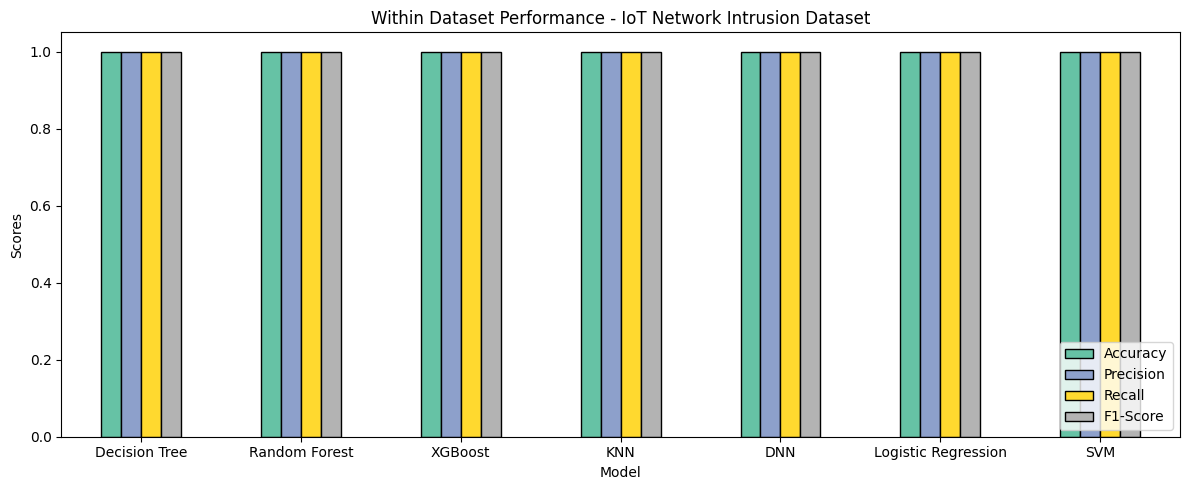

In [8]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].copy()
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Within Dataset Performance - IoT Network Intrusion Dataset")
plt.xlabel("Model")
plt.ylabel("Scores")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
#SHAP Feature Importance

#as SHAP is very slow on large datasets. A subsample of both train and test set will be taken

train_sample=shap.sample(X_train, 100, random_state=42)

test_sample=X_test.sample(200, random_state=42)

print(f"Train sample shape: {train_sample.shape}")
print(f"Test sample shape: {test_sample.shape}")


Train sample shape: (100, 102)
Test sample shape: (200, 102)


Computing SHAP values for Decision Tree...


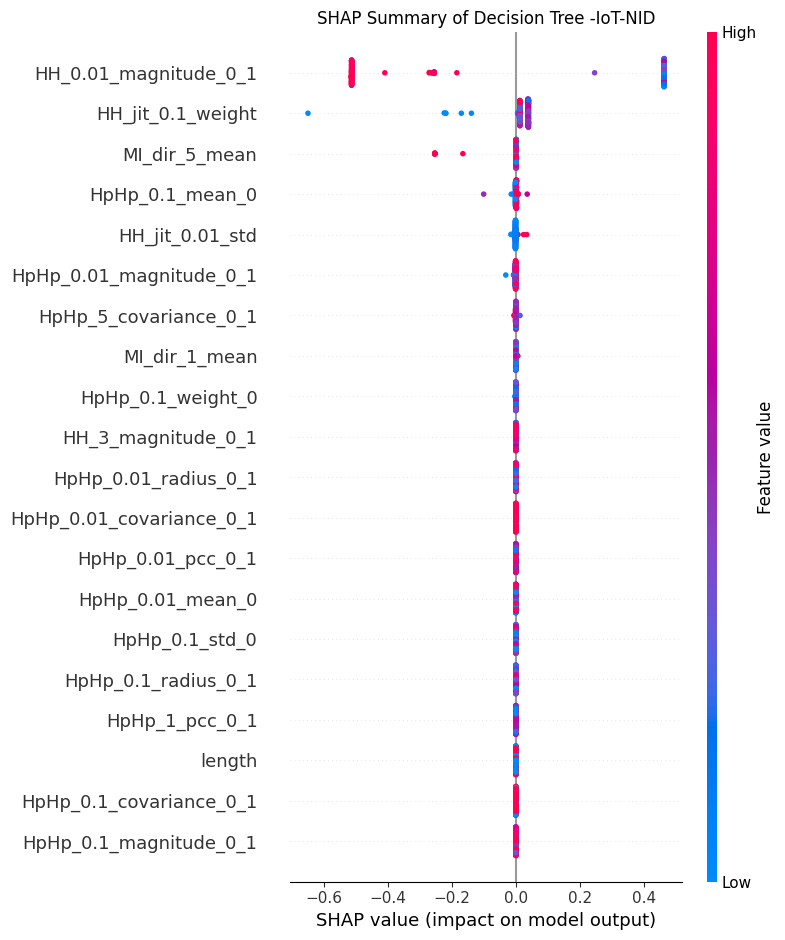

Computing SHAP values for Random Forest...


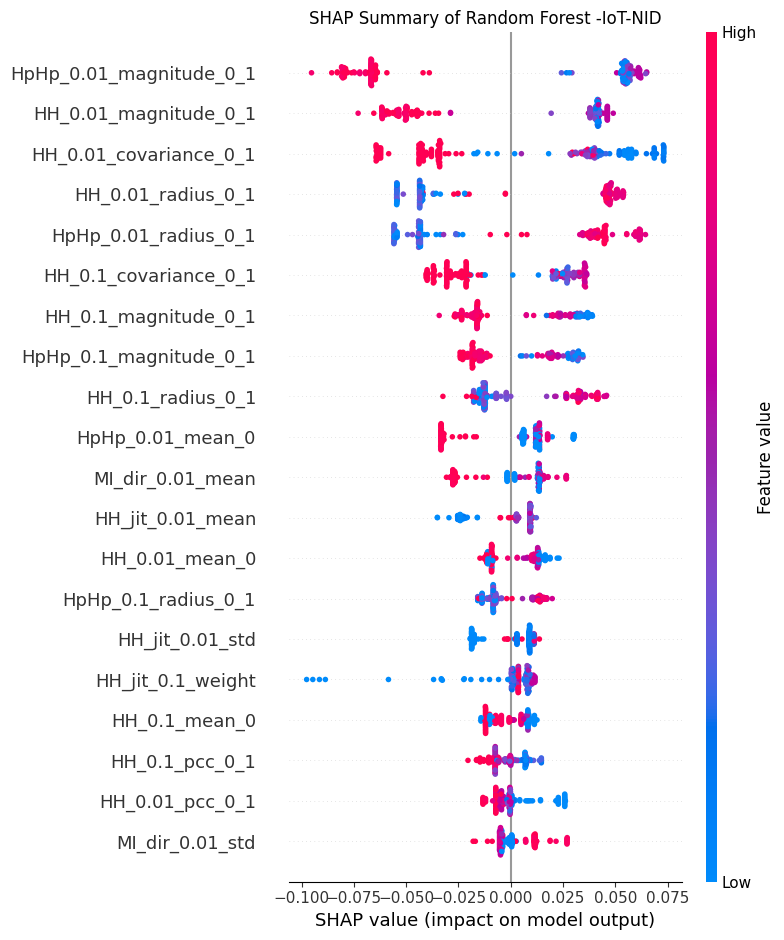

Computing SHAP values for XGBoost...


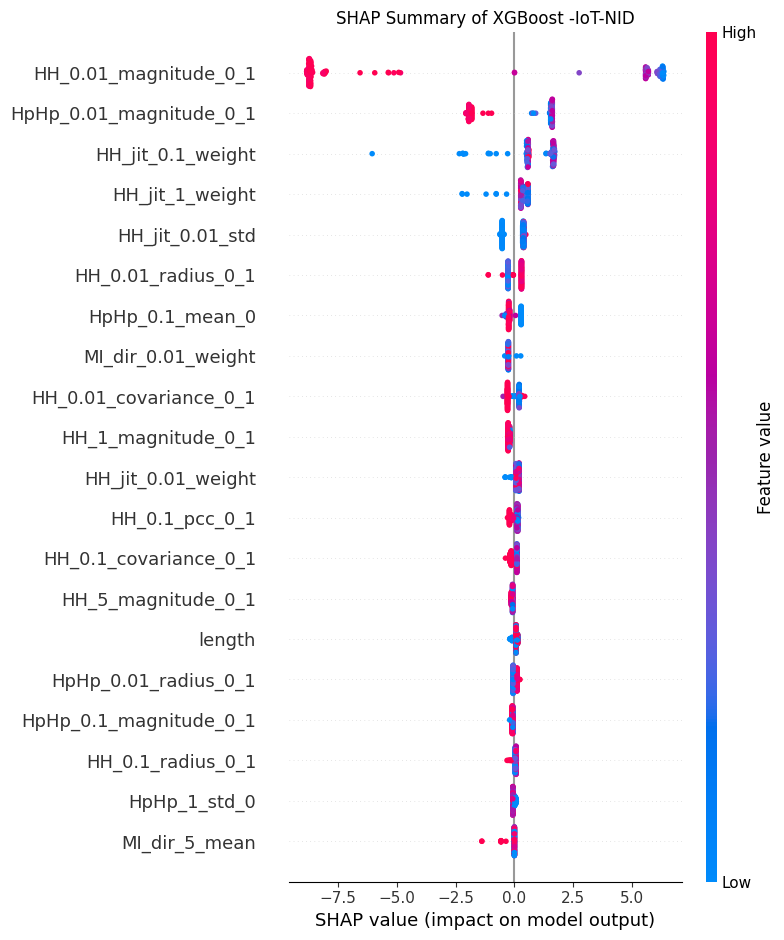

Tree-based SHAP values are calculated

Top 20 features for Decision Tree (IoT Network Intrusion Dataset): 
                Feature  Mean SHAP
  HH_0.01_magnitude_0_1   0.470469
      HH_jit_0.1_weight   0.032868
          MI_dir_5_mean   0.011783
        HpHp_0.1_mean_0   0.001911
        HH_jit_0.01_std   0.001683
HpHp_0.01_magnitude_0_1   0.001237
  HpHp_5_covariance_0_1   0.000599
          MI_dir_1_mean   0.000217
      HpHp_0.1_weight_0   0.000103
     HH_3_magnitude_0_1   0.000010
           MI_dir_3_std   0.000000
         MI_dir_0.1_std   0.000000
     MI_dir_0.01_weight   0.000000
      MI_dir_0.1_weight   0.000000
        MI_dir_0.01_std   0.000000
          MI_dir_3_mean   0.000000
           MI_dir_1_std   0.000000
        MI_dir_1_weight   0.000000
        MI_dir_0.1_mean   0.000000
     HH_5_magnitude_0_1   0.000000

Top 20 features for Random Forest (IoT Network Intrusion Dataset): 
                Feature  Mean SHAP
HpHp_0.01_magnitude_0_1   0.062882
  HH_0.01_magnitude

In [10]:
#SHAP for tree-based models (Decision Tree, Random Forest and XGBoost)

tree_based_models = ["Decision Tree", "Random Forest", "XGBoost"]
tree_shap_values={}

for model_name in tree_based_models:
    print(f"Computing SHAP values for {model_name}...")
    explainer=shap.TreeExplainer(models[model_name])
    shap_values=explainer.shap_values(test_sample)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    tree_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, test_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} -IoT-NID")
    plt.tight_layout()
    plt.show()

print("Tree-based SHAP values are calculated")

tree_imporatnce_table= {}
for model_name, shap_values in tree_shap_values.items():
    mean_abs_shap=np.abs(shap_values).mean(axis=0)
    importance_df=pd.DataFrame({"Feature":test_sample.columns,
                               "Mean SHAP":mean_abs_shap
                               }).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
    tree_imporatnce_table[model_name]=importance_df
    print(f"\nTop 20 features for {model_name} (IoT Network Intrusion Dataset): ")
    print(importance_df.head(20).to_string(index=False))

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.


Computing SHAP values for Logistic Regression...


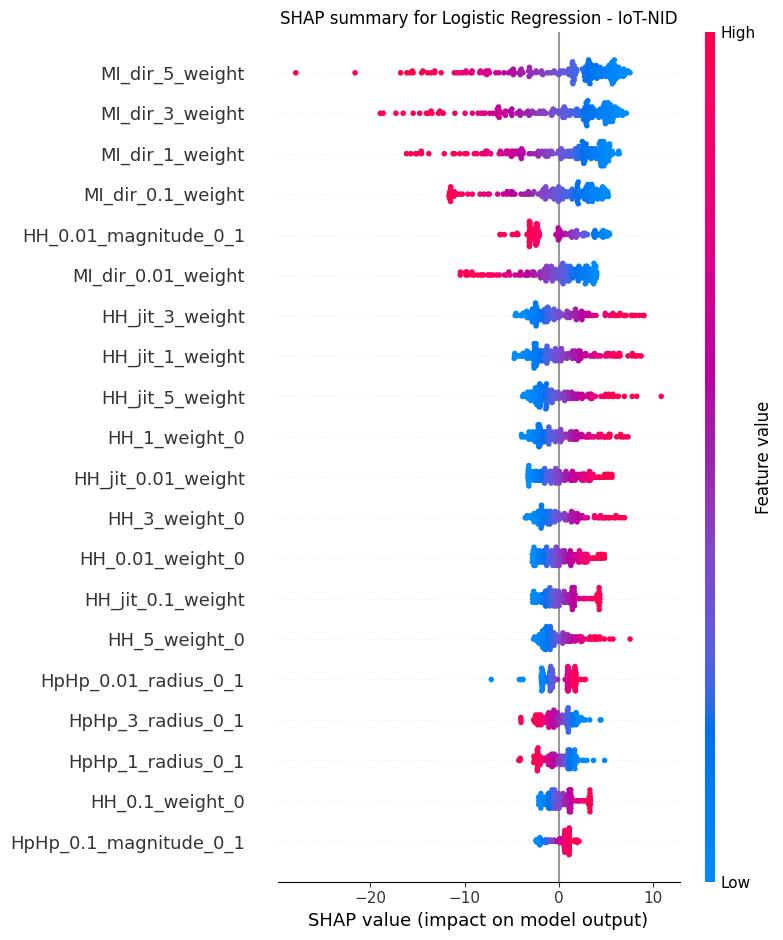


Top 20 features for Logistic Regression (IoT Network Intrusion Dataset):
               Feature  Mean SHAP
       MI_dir_5_weight   5.153884
       MI_dir_3_weight   4.699197
       MI_dir_1_weight   4.192439
     MI_dir_0.1_weight   3.429669
 HH_0.01_magnitude_0_1   2.646115
    MI_dir_0.01_weight   2.628239
       HH_jit_3_weight   2.464060
       HH_jit_1_weight   2.433483
       HH_jit_5_weight   2.128530
         HH_1_weight_0   2.032664
    HH_jit_0.01_weight   2.019806
         HH_3_weight_0   1.894158
      HH_0.01_weight_0   1.725946
     HH_jit_0.1_weight   1.525680
         HH_5_weight_0   1.480721
  HpHp_0.01_radius_0_1   1.372674
     HpHp_3_radius_0_1   1.323098
     HpHp_1_radius_0_1   1.254373
       HH_0.1_weight_0   1.170750
HpHp_0.1_magnitude_0_1   1.000337


In [11]:
#SHAP for Logistic Regression

print("Computing SHAP values for Logistic Regression...")
lr_explainer=shap.LinearExplainer(models['Logistic Regression'], X_train, max_samples=32000)
lr_shap_values=lr_explainer.shap_values(test_sample)

plt.figure()
shap.summary_plot(lr_shap_values, test_sample, show=False)
plt.title("SHAP summary for Logistic Regression - IoT-NID")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(lr_shap_values).mean(axis=0)
lr_importance_df = pd.DataFrame({
    "Feature": test_sample.columns,
    "Mean SHAP": mean_abs_shap
}).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
print("\nTop 20 features for Logistic Regression (IoT Network Intrusion Dataset):")
print(lr_importance_df.head(20).to_string(index=False))

Computing SHAP values for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [44:39<00:00, 53.60s/it]


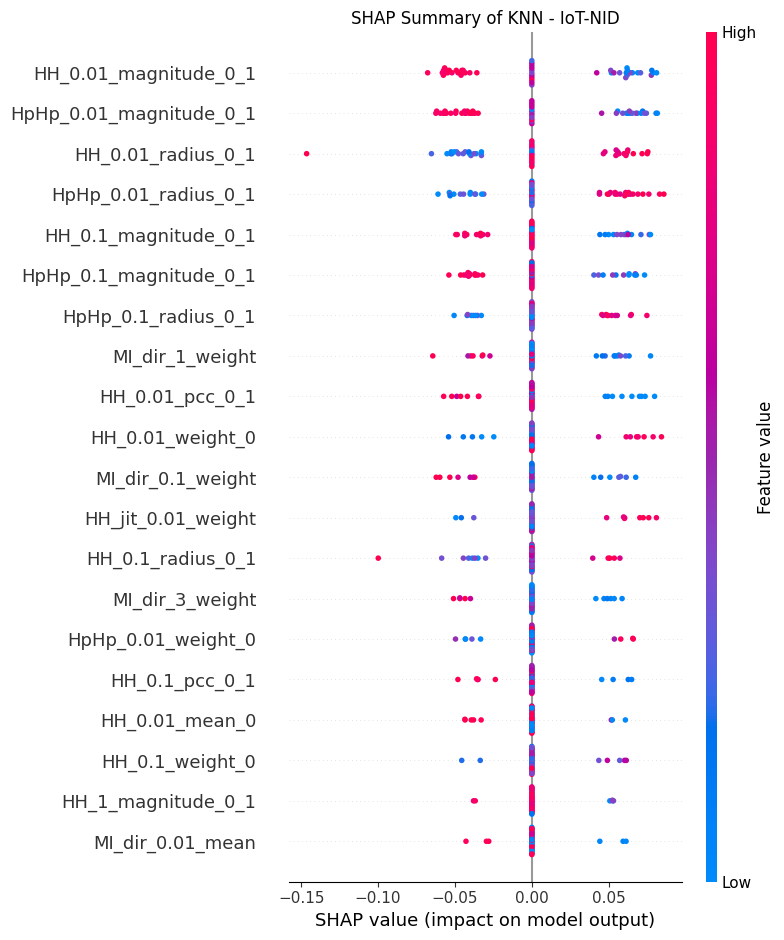

Computing SHAP values for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [22:15<00:00, 26.71s/it]


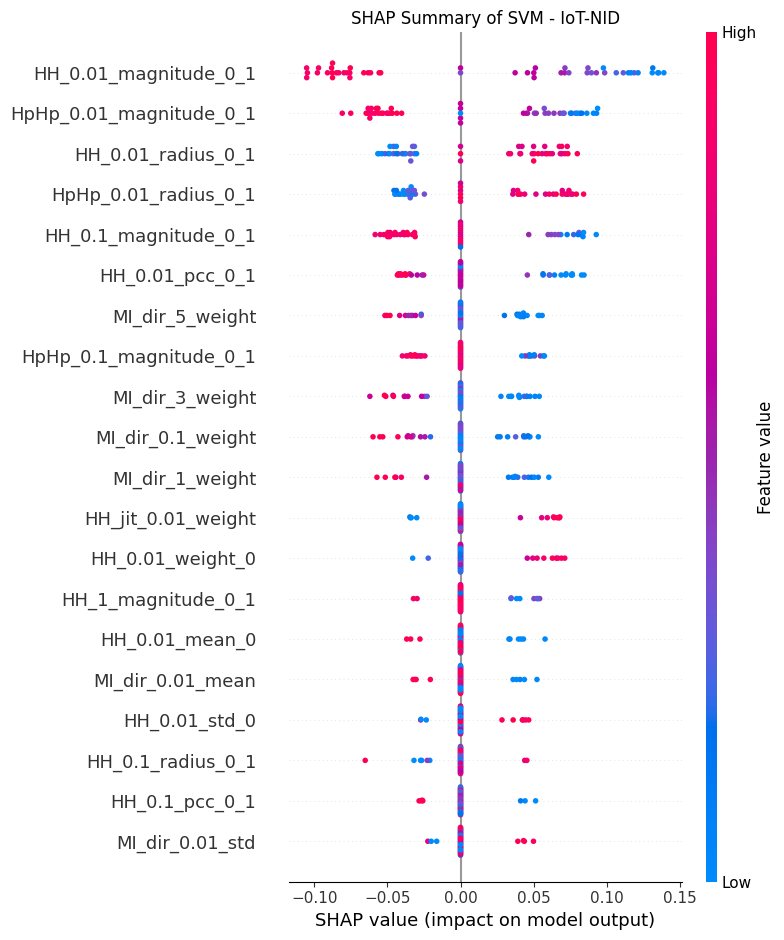

KNN and SVM SHAP values are calculated

Top 20 features for KNN (IoT Network Intrusion Dataset):
                Feature  Mean SHAP
  HH_0.01_magnitude_0_1   0.044407
HpHp_0.01_magnitude_0_1   0.042638
     HH_0.01_radius_0_1   0.038414
   HpHp_0.01_radius_0_1   0.037306
   HH_0.1_magnitude_0_1   0.026906
 HpHp_0.1_magnitude_0_1   0.026207
    HpHp_0.1_radius_0_1   0.018427
        MI_dir_1_weight   0.017804
        HH_0.01_pcc_0_1   0.017681
       HH_0.01_weight_0   0.014745
      MI_dir_0.1_weight   0.014361
     HH_jit_0.01_weight   0.013238
      HH_0.1_radius_0_1   0.012721
        MI_dir_3_weight   0.010588
     HpHp_0.01_weight_0   0.009031
         HH_0.1_pcc_0_1   0.008083
         HH_0.01_mean_0   0.007245
        HH_0.1_weight_0   0.007016
     HH_1_magnitude_0_1   0.005670
       MI_dir_0.01_mean   0.005306

Top 20 features for SVM (IoT Network Intrusion Dataset):
                Feature  Mean SHAP
  HH_0.01_magnitude_0_1   0.084886
HpHp_0.01_magnitude_0_1   0.056564
     

In [12]:
#SHAP for KNN and SVM

kernel_models = ["KNN", "SVM"]
kernel_sample=test_sample.sample(50, random_state=42)
kernel_shap_values = {}

for model_name in kernel_models:
    print(f"Computing SHAP values for {model_name}...")
    model=models[model_name]

    k_explainer=shap.KernelExplainer(model.predict_proba, train_sample)
    shap_values=k_explainer.shap_values(kernel_sample, nsample=100)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    kernel_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, kernel_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} - IoT-NID")
    plt.tight_layout()
    plt.show()

print("KNN and SVM SHAP values are calculated")

kernel_importance_tables = {}
for model_name, shap_values in kernel_shap_values.items():
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        "Feature": kernel_sample.columns,
        "Mean SHAP": mean_abs_shap
    }).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
    kernel_importance_tables[model_name] = importance_df
    print(f"\nTop 20 features for {model_name} (IoT Network Intrusion Dataset):")
    print(importance_df.head(20).to_string(index=False))

Computing SHAP values for DNN...


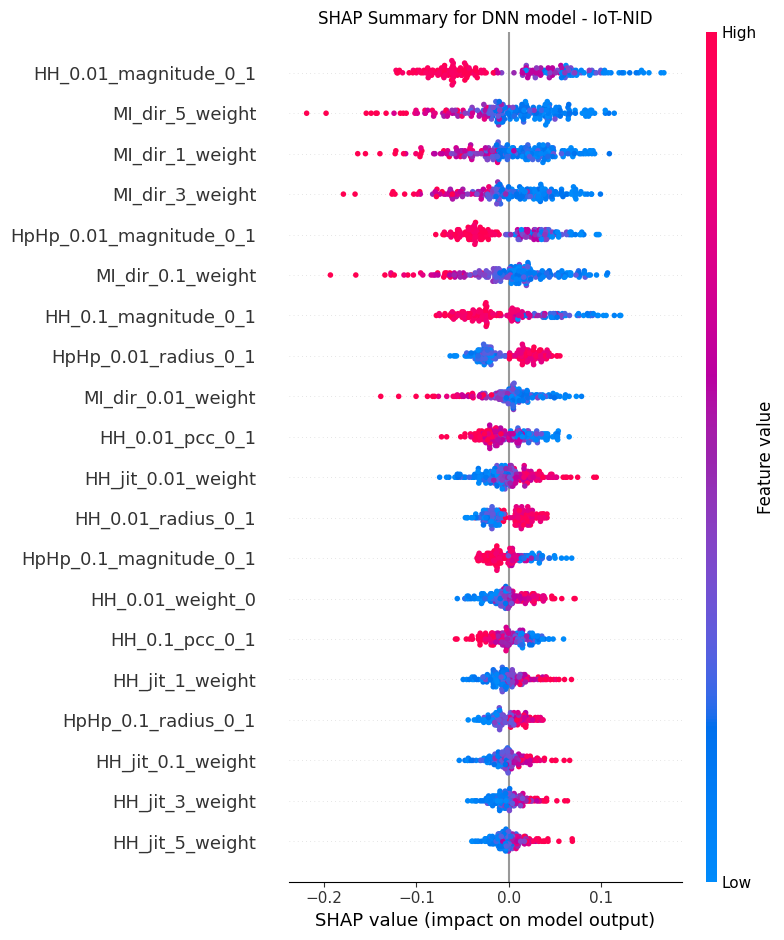

DNN SHAP values are calculated.

Top 20 features for DNN (IoT Network Intrusion Dataset):
                Feature  Mean SHAP
  HH_0.01_magnitude_0_1   0.063603
        MI_dir_5_weight   0.044914
        MI_dir_1_weight   0.040078
        MI_dir_3_weight   0.038230
HpHp_0.01_magnitude_0_1   0.038201
      MI_dir_0.1_weight   0.037822
   HH_0.1_magnitude_0_1   0.037561
   HpHp_0.01_radius_0_1   0.026084
     MI_dir_0.01_weight   0.022392
        HH_0.01_pcc_0_1   0.021452
     HH_jit_0.01_weight   0.021248
     HH_0.01_radius_0_1   0.019138
 HpHp_0.1_magnitude_0_1   0.016984
       HH_0.01_weight_0   0.016868
         HH_0.1_pcc_0_1   0.016586
        HH_jit_1_weight   0.014861
    HpHp_0.1_radius_0_1   0.013640
      HH_jit_0.1_weight   0.013492
        HH_jit_3_weight   0.013031
        HH_jit_5_weight   0.012844


In [13]:
#SHAP for DNN model

print("Computing SHAP values for DNN...")

dnn_model=models["DNN"].model_
dnn_model.eval()

train_sample_t=torch.tensor(train_sample.values.astype('float32'))
test_sample_t=torch.tensor(test_sample.values.astype('float32'))

dnn_explainer=shap.GradientExplainer(dnn_model, test_sample_t)
dnn_shap_values=dnn_explainer.shap_values(test_sample_t)

if isinstance(dnn_shap_values, list):
    dnn_shap_values=dnn_shap_values[0]

dnn_shap_values=np.squeeze(dnn_shap_values)

plt.figure()
shap.summary_plot(dnn_shap_values, test_sample, show=False)
plt.title("SHAP Summary for DNN model - IoT-NID")
plt.tight_layout()
plt.show()

print("DNN SHAP values are calculated.")

mean_abs_shap = np.abs(dnn_shap_values).mean(axis=0)
dnn_importance_df = pd.DataFrame({
    "Feature": test_sample.columns,
    "Mean SHAP": mean_abs_shap
}).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
print("\nTop 20 features for DNN (IoT Network Intrusion Dataset):")
print(dnn_importance_df.head(20).to_string(index=False))

In [15]:
# Combine top-20 feature sets from all 7 models and print the common (intersection) features
all_top20 = {}

for model_name, df in tree_imporatnce_table.items():
    all_top20[model_name] = set(df["Feature"].head(20))

all_top20["Logistic Regression"] = set(lr_importance_df["Feature"].head(20))

for model_name, df in kernel_importance_tables.items():
    all_top20[model_name] = set(df["Feature"].head(20))

all_top20["DNN"] = set(dnn_importance_df["Feature"].head(20))

print(f"Models included in intersection: {list(all_top20.keys())}\n")

common_features = set.intersection(*all_top20.values())
print(f"Features in top20 across all {len(all_top20)} models are: {common_features}")

# How many of the models each feature appears in ( if the above intersection is empty or very small)
from collections import Counter
feature_counts = Counter()
for features in all_top20.values():
    for f in features:
        feature_counts[f] += 1

coverage_df = pd.DataFrame(
    feature_counts.most_common(),
    columns=["Feature", "Models".format(len(all_top20))]
)
print("\nFeature coverage across all models (IoT Network Intrusion Dataset), most consistent first:")
print(coverage_df.to_string(index=False))

Models included in intersection: ['Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression', 'KNN', 'SVM', 'DNN']

Features in top20 across all 7 models are: {'HH_0.01_magnitude_0_1'}

Feature coverage across all models (IoT Network Intrusion Dataset), most consistent first:
                Feature  Models
  HH_0.01_magnitude_0_1       7
HpHp_0.01_magnitude_0_1       6
 HpHp_0.1_magnitude_0_1       6
   HpHp_0.01_radius_0_1       6
      HH_jit_0.1_weight       5
        MI_dir_1_weight       5
      MI_dir_0.1_weight       5
     HH_0.01_radius_0_1       5
         HH_0.1_pcc_0_1       5
     HH_jit_0.01_weight       5
     MI_dir_0.01_weight       4
      HH_0.1_radius_0_1       4
        HH_0.01_pcc_0_1       4
   HH_0.1_magnitude_0_1       4
       HH_0.01_weight_0       4
        MI_dir_3_weight       4
        MI_dir_0.01_std       3
        HH_jit_0.01_std       3
    HpHp_0.1_radius_0_1       3
         HH_0.01_mean_0       3
       MI_dir_0.01_mean       3
        HH_